In [1]:
import numpy as np
from qutip import *
from scipy.linalg import sqrtm, eigvalsh
from scipy.stats import linregress
from numba import njit, prange
import pickle
import os
import gc

In [2]:
%matplotlib ipympl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image, display, Math

## Results Analysis

In [3]:
# ====================================
# Physical & Simulation Parameters
# ====================================

# Site selector: 0 for |10>, 1 for |01>
site_index = 0

# Time parameters
dt = 0.01
tf = 100.0
time_steps = int(tf / dt)

# List of Number of trajectories to analyze
N_traj_list = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 20000]        

In [4]:
# ============================================================
# GLOBAL CONFIGURATION
# ============================================================
import os

MODE = 'close_to_90'   # Options: 'normal' or 'close_to_90'

# Configuration mapping based on MODE
_cfg = {
    'normal': {
        'Input_dir': "../Results/Data/Complete_rho/normal/pauli_exp_value",
        'thetas_deg': [0, 30, 45, 60, 90],
        'Output_dir': "../Results/Plot/Sxyz_exp_value/Avg/normal" 
    },
    'close_to_90': {
        'Input_dir': "../Results/Data/Complete_rho/close_90_deg/pauli_exp_value",
        'thetas_deg': [90.0, 89.9, 89.7, 89.5, 89.0, 88.5, 88.0, 87.0, 86.0],
        'Output_dir': "../Results/Plot/Sxyz_exp_value/Avg/close_to_90"
    },
}

# Apply the selected configuration
cfg = _cfg[MODE]

# Base output directory
base_output_dir = cfg['Output_dir']
os.makedirs(base_output_dir, exist_ok=True)

print(f"--- Configuration Setup ---")
print(f"Current mode : {MODE}")
print(f"Angles list  : {cfg['thetas_deg']}")
print(f"Input Data   : {cfg['Input_dir']}")
print(f"Base Output  : {base_output_dir}")

--- Configuration Setup ---
Current mode : close_to_90
Angles list  : [90.0, 89.9, 89.7, 89.5, 89.0, 88.5, 88.0, 87.0, 86.0]
Input Data   : ../Results/Data/Complete_rho/close_90_deg/pauli_exp_value
Base Output  : ../Results/Plot/Sxyz_exp_value/Avg/close_to_90


In [5]:
# ===========================
# General Setup for Plotting
# ===========================

# Global Style Settings (Matplotlib rcParams)
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'figure.figsize': (10, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': ':',
    'figure.autolayout': True # plt.tight_layout()
})

# Automatic Figure Saving Function
def save_fig(fig, filename):
    """
    Saves the figure in both PNG or PDF
    """
    path_png = os.path.join(Output_dir, f"{filename}.png")
    # path_pdf = os.path.join(Output_dir, f"{filename}.pdf")  # save in pdf
    
    fig.savefig(path_png, dpi=300, bbox_inches='tight')
    # fig.savefig(path_pdf, bbox_inches='tight') # save in pdf
    print(f"Figure saved in: {Output_dir}/{filename}")

### Data Extraction

In [6]:
# ====================
# Lindblad Extraction
# ====================

print("Starting Lindblad data extraction")

# Single extraction for Lindbad data, since they don't depend on theta !

# Format theta and dt for filename 
Lindblad_theta_rad = np.deg2rad(90)  # Always 90° for Lindblad

Lindblad_theta_str = f"{Lindblad_theta_rad:.6f}".replace(".", "p")
Lindblad_dt_str = f"{dt:.6f}".replace(".", "p")

 # File name
Lindbald_input_dir = "../Results/Data/Complete_rho/normal/"
Lindblad_filename = f"result_theta{Lindblad_theta_str}_dt{Lindblad_dt_str}_Ntraj20000.npz"
Lindblad_filepath = os.path.join(Lindbald_input_dir, Lindblad_filename)

Lindblad_data = np.load(Lindblad_filepath)

rho_lindblad_complete = Lindblad_data['rho_list_lindblad']  # 4x4 dimension

rho_lindblad = np.zeros((time_steps, 2, 2), dtype=np.complex128)

for t in range(time_steps):
    
    # Populations : Index (2,2) -> |10><10|, Index (1,1)  -> |01><01| INVERTED respect to Trajectories, already inverted here
    rho_lindblad[t, 0, 0] = rho_lindblad_complete[t, 2, 2]  # |10><10|
    rho_lindblad[t, 1, 1] = rho_lindblad_complete[t, 1, 1]  # |01><01|
    
    # Coherences ATTENTION : inverted respect to Trajectories, already inverted here
    rho_lindblad[t, 0, 1] = rho_lindblad_complete[t, 2, 1]  # |10><01|
    rho_lindblad[t, 1, 0] = rho_lindblad_complete[t, 1, 2]  # |01><10|

# ===========================
# LINDBLAD PAULI OBSERVABLES 
# ===========================

lindblad_sx = np.real(rho_lindblad[:, 0, 1] + rho_lindblad[:, 1, 0])
lindblad_sy = np.real(1j * (rho_lindblad[:, 1, 0] - rho_lindblad[:, 0, 1]))
lindblad_sz = np.real(rho_lindblad[:, 0, 0] - rho_lindblad[:, 1, 1])

print(" Lindblad data extraction completed")


Starting Lindblad data extraction
 Lindblad data extraction completed


In [7]:
# ====================================================================
# TRAJECTORY DATA EXTRACTION LOOP FOR Sx, Sy, Sz ERRORS
# ====================================================================

# Dictionaries to store the time-averaged and maximum ERROR for each N
# Structure: dict[theta][N] = single_scalar_value
mean_err_sx_results = {}
max_err_sx_results  = {}
mean_err_sy_results = {}
max_err_sy_results  = {}
mean_err_sz_results = {}
max_err_sz_results  = {}

for theta in cfg['thetas_deg']:
    print(f"\nProcessing angle: {theta}°...")
    
    # Initialize nested dictionaries for the current angle
    mean_err_sx_results[theta] = {}
    max_err_sx_results[theta]  = {}
    mean_err_sy_results[theta] = {}
    max_err_sy_results[theta]  = {}
    mean_err_sz_results[theta] = {}
    max_err_sz_results[theta]  = {}
    
    # Define exact filepaths using your saved filenames
    filepath_sx = os.path.join(cfg['Input_dir'], "Sx", f"Complete_Sx_Theta_{theta}deg.npz")
    filepath_sy = os.path.join(cfg['Input_dir'], "Sy", f"Complete_Sy_Theta_{theta}deg.npz")
    filepath_sz = os.path.join(cfg['Input_dir'], "Sz", f"Complete_Sz_Theta_{theta}deg.npz")
    
    try:
        # Load compressed data matrices for Sx, Sy, Sz
        data_sx = np.load(filepath_sx)
        data_sy = np.load(filepath_sy)
        data_sz = np.load(filepath_sz)
        
        all_sigma_x = data_sx['all_sigma_x']  
        all_sigma_y = data_sy['all_sigma_y']
        all_sigma_z = data_sz['all_sigma_z']
        
    except FileNotFoundError as e:
        print(f"Warning: Missing files for angle {theta}°. Skipping...")
        continue
        
    print(f"Data extraction for {theta}° completed. Starting N_trajectories loop...")

    # Loop over the number of trajectories
    for N in N_traj_list:
        
        # 1. Calculate the ensemble average over N trajectories for each time step
        sx_ensemble_mean = np.mean(all_sigma_x[:, :N], axis=1)
        sy_ensemble_mean = np.mean(all_sigma_y[:, :N], axis=1)
        sz_ensemble_mean = np.mean(all_sigma_z[:, :N], axis=1)
        
        # 2. Calculate the absolute error w.r.t. the exact Lindblad solution
        err_sx = np.abs(sx_ensemble_mean - lindblad_sx)
        err_sy = np.abs(sy_ensemble_mean - lindblad_sy)
        err_sz = np.abs(sz_ensemble_mean - lindblad_sz)
        
        # 3. Calculate the time-averaged value of the error
        mean_err_sx_results[theta][N] = np.mean(err_sx)
        mean_err_sy_results[theta][N] = np.mean(err_sy)
        mean_err_sz_results[theta][N] = np.mean(err_sz)
        
        # 4. Calculate the maximum value over time of the error
        max_err_sx_results[theta][N] = np.max(err_sx)
        max_err_sy_results[theta][N] = np.max(err_sy)
        max_err_sz_results[theta][N] = np.max(err_sz)
        
    # Close files and free memory to prevent RAM overload
    data_sx.close()
    data_sy.close()
    data_sz.close()
    del all_sigma_x, all_sigma_y, all_sigma_z, data_sx, data_sy, data_sz
    gc.collect()
    
    print(f"Angle {theta}° fully processed and memory cleared.")

print("\n--- All angles processed successfully! ---")


Processing angle: 90.0°...
Data extraction for 90.0° completed. Starting N_trajectories loop...
Angle 90.0° fully processed and memory cleared.

Processing angle: 89.9°...
Data extraction for 89.9° completed. Starting N_trajectories loop...
Angle 89.9° fully processed and memory cleared.

Processing angle: 89.7°...
Data extraction for 89.7° completed. Starting N_trajectories loop...
Angle 89.7° fully processed and memory cleared.

Processing angle: 89.5°...
Data extraction for 89.5° completed. Starting N_trajectories loop...
Angle 89.5° fully processed and memory cleared.

Processing angle: 89.0°...
Data extraction for 89.0° completed. Starting N_trajectories loop...
Angle 89.0° fully processed and memory cleared.

Processing angle: 88.5°...
Data extraction for 88.5° completed. Starting N_trajectories loop...
Angle 88.5° fully processed and memory cleared.

Processing angle: 88.0°...
Data extraction for 88.0° completed. Starting N_trajectories loop...
Angle 88.0° fully processed and m

## Plot

Created directory: ../Results/Plot/Sxyz_exp_value/Avg/close_to_90/Sz
Figure saved in: ../Results/Plot/Sxyz_exp_value/Avg/close_to_90/Sz/Mean_Max_Error_Sz


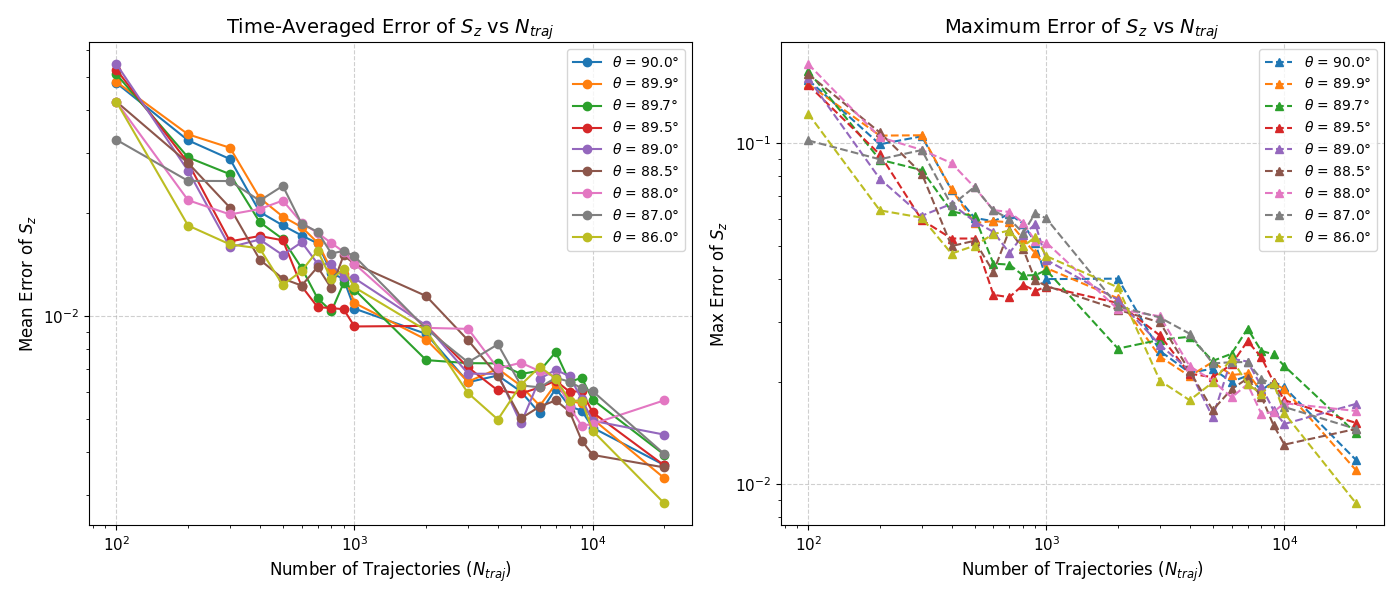

In [8]:
# ========================================================
# MEAN AND MAX ERROR OF Sz VS N_TRAJECTORIES
# ========================================================

# Create a figure with 2 subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- First Subplot: Mean Error ---
for theta in cfg['thetas_deg']:
    y_mean_sz = [mean_err_sz_results[theta][N] for N in N_traj_list]
    ax1.plot(N_traj_list, y_mean_sz, marker='o', linestyle='-', label=f'$\\theta$ = {theta}°')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Number of Trajectories ($N_{traj}$)', fontsize=12)
ax1.set_ylabel('Mean Error of $S_z$', fontsize=12)
ax1.set_title('Time-Averaged Error of $S_z$ vs $N_{traj}$', fontsize=14)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Second Subplot: Max Error ---
for theta in cfg['thetas_deg']:
    y_max_sz = [max_err_sz_results[theta][N] for N in N_traj_list]
    ax2.plot(N_traj_list, y_max_sz, marker='^', linestyle='--', label=f'$\\theta$ = {theta}°')

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Number of Trajectories ($N_{traj}$)', fontsize=12)
ax2.set_ylabel('Max Error of $S_z$', fontsize=12)
ax2.set_title('Maximum Error of $S_z$ vs $N_{traj}$', fontsize=14)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlapping
plt.tight_layout()

# ---------------------
# FIGURE SAVING FOR Sz
# ---------------------

# Dynamically set the output directory using the base path
Output_dir = os.path.join(base_output_dir, "Sz")

# Check if the directory exists, otherwise create it
if not os.path.exists(Output_dir):
    os.makedirs(Output_dir)
    print(f"Created directory: {Output_dir}")

# Save the figure 
save_fig(plt.gcf(), "Mean_Max_Error_Sz")

plt.show()

--- Angle-by-Angle Fit Results: Mean Error of Sz ---
Angle 90.0° -> Slope: -0.4800 | Intercept: -0.4296 | R^2: 0.9712
Angle 89.9° -> Slope: -0.4882 | Intercept: -0.3900 | R^2: 0.9700
Angle 89.7° -> Slope: -0.4036 | Intercept: -0.6702 | R^2: 0.9046
Angle 89.5° -> Slope: -0.4034 | Intercept: -0.7114 | R^2: 0.9024
Angle 89.0° -> Slope: -0.4108 | Intercept: -0.6561 | R^2: 0.9201
Angle 88.5° -> Slope: -0.4419 | Intercept: -0.5858 | R^2: 0.9498
Angle 88.0° -> Slope: -0.4104 | Intercept: -0.6215 | R^2: 0.9555
Angle 87.0° -> Slope: -0.4160 | Intercept: -0.5994 | R^2: 0.9709
Angle 86.0° -> Slope: -0.4017 | Intercept: -0.7281 | R^2: 0.9192
Figure saved in: ../Results/Plot/Sxyz_exp_value/Avg/close_to_90/Sz/Fit_Error_Sz


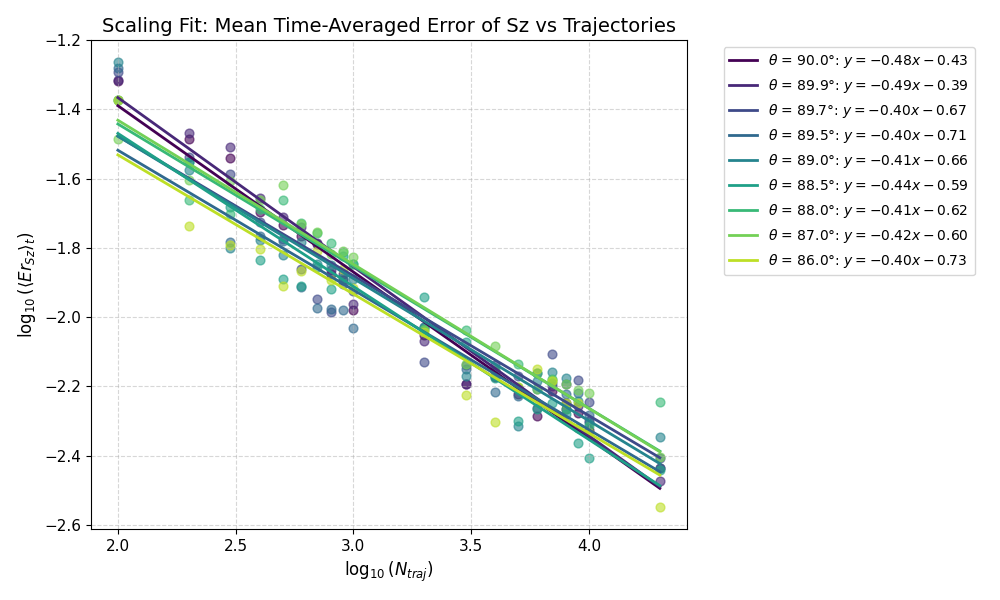

In [9]:
# ====================================================================
# ANGLE-BY-ANGLE FIT & PLOT: MEAN ERROR OF Sz vs N_TRAJ
# ====================================================================
plt.figure(figsize=(10, 6))

print("--- Angle-by-Angle Fit Results: Mean Error of Sz ---")

# Create a color map to easily distinguish different angles in the plot
colors = plt.cm.viridis(np.linspace(0, 0.9, len(cfg['thetas_deg'])))

for idx, theta in enumerate(cfg['thetas_deg']):
    # Extract the error values for this angle
    mean_err_sz_dict = mean_err_sz_results[theta]
    
    # Filter valid points (strict positive for log10)
    valid_N = []
    valid_err = []
    for N in N_traj_list:
        err_val = mean_err_sz_dict[N]
        if err_val > 0:
            valid_N.append(N)
            valid_err.append(err_val)
            
    # Convert lists to arrays for math operations
    x_data = np.array(valid_N)
    y_data = np.array(valid_err)
    
    # Take logarithms for the log-log fit
    log_x = np.log10(x_data)
    log_y = np.log10(y_data)
    
    # Perform linear regression: log(Error) = slope * log(N) + intercept
    slope, intercept, r_value, p_value, std_err = linregress(log_x, log_y)
    print(f"Angle {theta:^4}° -> Slope: {slope:+.4f} | Intercept: {intercept:+.4f} | R^2: {r_value**2:.4f}")
    
    color = colors[idx]
    
    # Plot the original scatter points in log-log space (we handle log manually via axes later)
    # Using raw log values to overlay the fit properly
    plt.scatter(log_x, log_y, color=color, alpha=0.6, marker='o', s=40)
    
    # Generate the theoretical fit line points
    x_fit = np.linspace(min(log_x), max(log_x), 100)
    y_fit = slope * x_fit + intercept
    
    # Plot the fit line and include the equation in the legend
    plt.plot(x_fit, y_fit, color=color, linewidth=2, 
             label=f'$\\theta$ = {theta}°: $y = {slope:.2f}x {intercept:+.2f}$')

# Formatting the plot
plt.xlabel(r"$\log_{10}(N_{traj})$", fontsize=12)
plt.ylabel(r"$\log_{10}(\langle Er_{Sz} \rangle_t)$", fontsize=12)
plt.title("Scaling Fit: Mean Time-Averaged Error of Sz vs Trajectories", fontsize=14)

# Place the legend outside the plot area
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# ---------------------
# FIGURE SAVING FOR Sz
# ---------------------

# Dynamically set the output directory using the base path
Output_dir = os.path.join(base_output_dir, "Sz")

# Check if the directory exists, otherwise create it
if not os.path.exists(Output_dir):
    os.makedirs(Output_dir)
    print(f"Created directory: {Output_dir}")

# Save the figure 
save_fig(plt.gcf(), "Fit_Error_Sz")

plt.show()

Created directory: ../Results/Plot/Sxyz_exp_value/Avg/close_to_90/Sx
Figure saved in: ../Results/Plot/Sxyz_exp_value/Avg/close_to_90/Sx/Mean_Max_Error_Sx


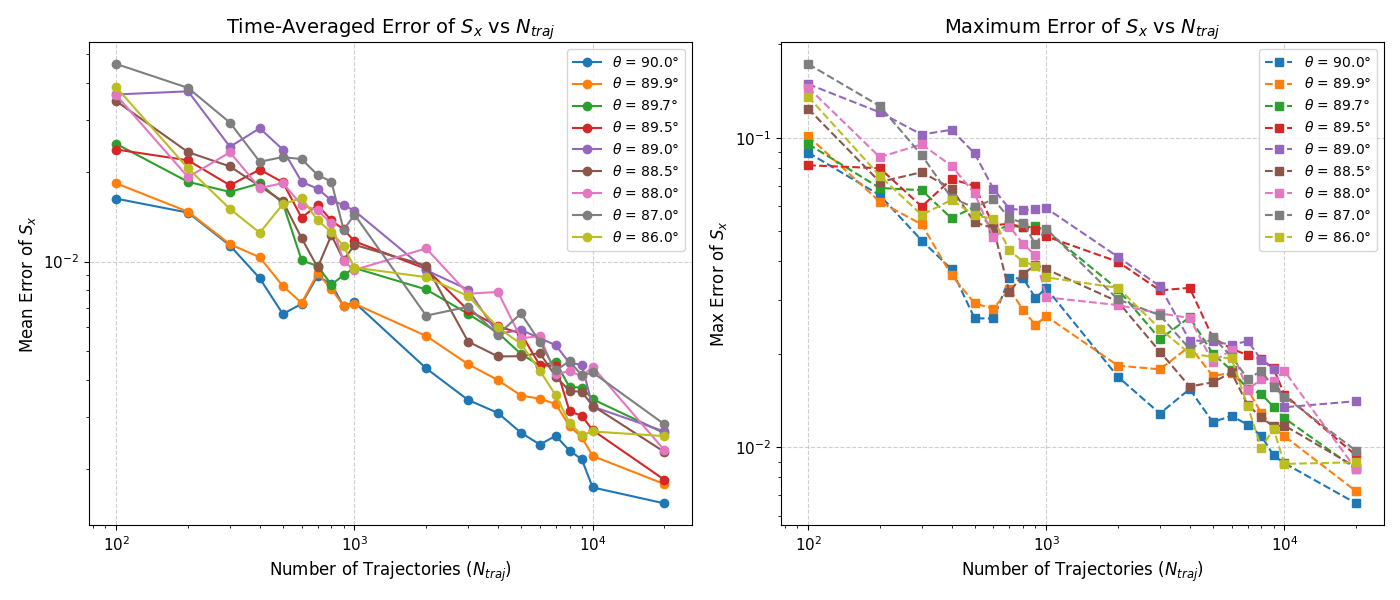

In [10]:
# ========================================================
# MEAN AND MAX ERROR OF Sx VS N_TRAJECTORIES
# ========================================================

# Create a figure with 2 subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- First Subplot: Mean Error ---
for theta in cfg['thetas_deg']:
    # Retrieve the list of mean error values for this angle
    y_mean_sx = [mean_err_sx_results[theta][N] for N in N_traj_list]
    # Plot connecting points with a solid line
    ax1.plot(N_traj_list, y_mean_sx, marker='o', linestyle='-', label=f'$\\theta$ = {theta}°')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Number of Trajectories ($N_{traj}$)', fontsize=12)
ax1.set_ylabel('Mean Error of $S_x$', fontsize=12)
ax1.set_title('Time-Averaged Error of $S_x$ vs $N_{traj}$', fontsize=14)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Second Subplot: Max Error ---
for theta in cfg['thetas_deg']:
    # Retrieve the list of max error values for this angle
    y_max_sx = [max_err_sx_results[theta][N] for N in N_traj_list]
    # Plot connecting points with a dashed line
    ax2.plot(N_traj_list, y_max_sx, marker='s', linestyle='--', label=f'$\\theta$ = {theta}°')

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Number of Trajectories ($N_{traj}$)', fontsize=12)
ax2.set_ylabel('Max Error of $S_x$', fontsize=12)
ax2.set_title('Maximum Error of $S_x$ vs $N_{traj}$', fontsize=14)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlapping
plt.tight_layout()

# ---------------------
# FIGURE SAVING FOR Sx
# ---------------------

# Dynamically set the output directory using the base path
Output_dir = os.path.join(base_output_dir, "Sx")

# Check if the directory exists, otherwise create it
if not os.path.exists(Output_dir):
    os.makedirs(Output_dir)
    print(f"Created directory: {Output_dir}")

# Save the figure 
save_fig(plt.gcf(), "Mean_Max_Error_Sx")

plt.show()

--- Angle-by-Angle Fit Results: Mean Error of Sx ---
Angle 90.0° -> Slope: -0.4828 | Intercept: -0.7627 | R^2: 0.9732
Angle 89.9° -> Slope: -0.4332 | Intercept: -0.8589 | R^2: 0.9843
Angle 89.7° -> Slope: -0.4254 | Intercept: -0.7395 | R^2: 0.9659
Angle 89.5° -> Slope: -0.5165 | Intercept: -0.4100 | R^2: 0.9516
Angle 89.0° -> Slope: -0.5462 | Intercept: -0.2133 | R^2: 0.9802
Angle 88.5° -> Slope: -0.5011 | Intercept: -0.4723 | R^2: 0.9777
Angle 88.0° -> Slope: -0.4685 | Intercept: -0.5215 | R^2: 0.9556
Angle 87.0° -> Slope: -0.5621 | Intercept: -0.1622 | R^2: 0.9751
Angle 86.0° -> Slope: -0.5119 | Intercept: -0.4471 | R^2: 0.9511
Figure saved in: ../Results/Plot/Sxyz_exp_value/Avg/close_to_90/Sx/Fit_Error_Sx


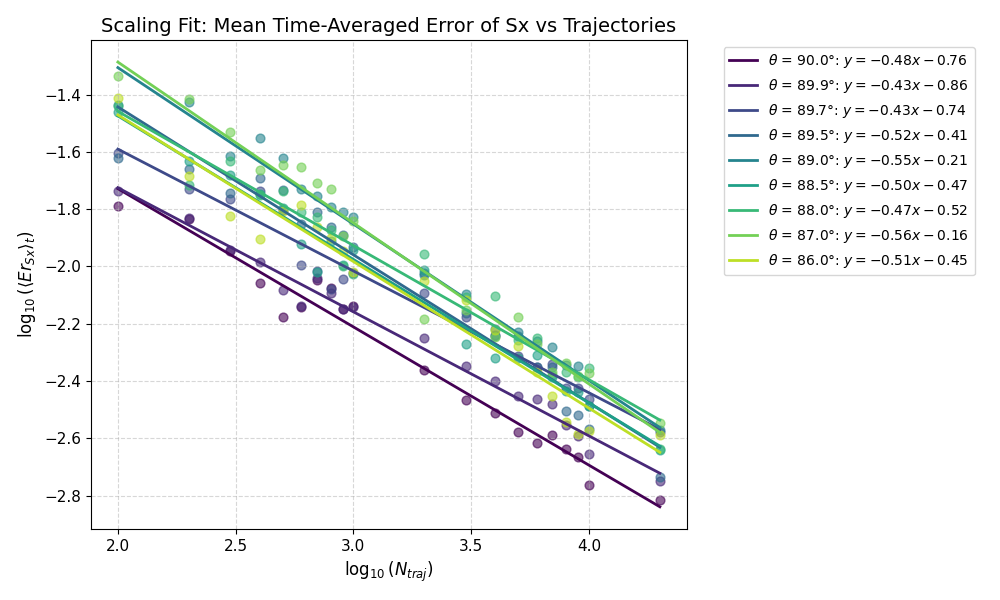

In [11]:
# ====================================================================
# ANGLE-BY-ANGLE FIT & PLOT: MEAN ERROR OF Sx vs N_TRAJ
# ====================================================================
plt.figure(figsize=(10, 6))

print("--- Angle-by-Angle Fit Results: Mean Error of Sx ---")

# Create a color map to easily distinguish different angles in the plot
colors = plt.cm.viridis(np.linspace(0, 0.9, len(cfg['thetas_deg'])))

for idx, theta in enumerate(cfg['thetas_deg']):
    # Extract the error values for this angle
    mean_err_sx_dict = mean_err_sx_results[theta]
    
    # Filter valid points (must be strictly positive for log10)
    valid_N = []
    valid_err = []
    for N in N_traj_list:
        err_val = mean_err_sx_dict[N]
        if err_val > 0:
            valid_N.append(N)
            valid_err.append(err_val)
            
    # Convert lists to arrays for math operations
    x_data = np.array(valid_N)
    y_data = np.array(valid_err)
    
    # Take logarithms for the log-log fit
    log_x = np.log10(x_data)
    log_y = np.log10(y_data)
    
    # Perform linear regression: log(Error) = slope * log(N) + intercept
    slope, intercept, r_value, p_value, std_err = linregress(log_x, log_y)
    print(f"Angle {theta:^4}° -> Slope: {slope:+.4f} | Intercept: {intercept:+.4f} | R^2: {r_value**2:.4f}")
    
    color = colors[idx]
    
    # Plot the original scatter points in log-log space
    plt.scatter(log_x, log_y, color=color, alpha=0.6, marker='o', s=40)
    
    # Generate the theoretical fit line points
    x_fit = np.linspace(min(log_x), max(log_x), 100)
    y_fit = slope * x_fit + intercept
    
    # Plot the fit line and include the equation in the legend
    plt.plot(x_fit, y_fit, color=color, linewidth=2, 
             label=f'$\\theta$ = {theta}°: $y = {slope:.2f}x {intercept:+.2f}$')

# Formatting the plot
plt.xlabel(r"$\log_{10}(N_{traj})$", fontsize=12)
plt.ylabel(r"$\log_{10}(\langle Er_{Sx} \rangle_t)$", fontsize=12)
plt.title("Scaling Fit: Mean Time-Averaged Error of Sx vs Trajectories", fontsize=14)

# Place the legend outside the plot area
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# ---------------------
# FIGURE SAVING FOR Sx
# ---------------------

# Dynamically set the output directory using the base path
Output_dir = os.path.join(base_output_dir, "Sx")

# Check if the directory exists, otherwise create it
if not os.path.exists(Output_dir):
    os.makedirs(Output_dir)
    print(f"Created directory: {Output_dir}")

# Save the figure 
save_fig(plt.gcf(), "Fit_Error_Sx")

# Display the plot
plt.show()

Created directory: ../Results/Plot/Sxyz_exp_value/Avg/close_to_90/Sy
Figure saved in: ../Results/Plot/Sxyz_exp_value/Avg/close_to_90/Sy/Mean_Max_Error_Sy


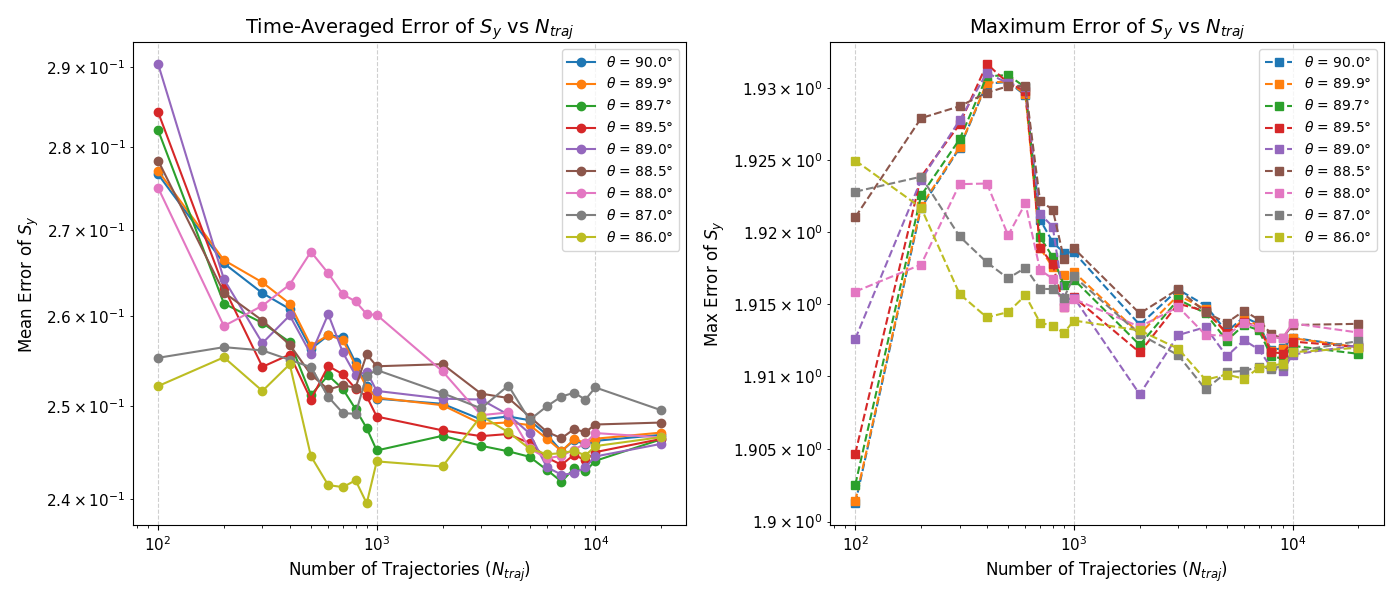

In [12]:
# ========================================================
# MEAN AND MAX ERROR OF Sy VS N_TRAJECTORIES
# ========================================================

# Create a figure with 2 subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- First Subplot: Mean Error ---
for theta in cfg['thetas_deg']:
    y_mean_sy = [mean_err_sy_results[theta][N] for N in N_traj_list]
    ax1.plot(N_traj_list, y_mean_sy, marker='o', linestyle='-', label=f'$\\theta$ = {theta}°')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Number of Trajectories ($N_{traj}$)', fontsize=12)
ax1.set_ylabel('Mean Error of $S_y$', fontsize=12)
ax1.set_title('Time-Averaged Error of $S_y$ vs $N_{traj}$', fontsize=14)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Second Subplot: Max Error ---
for theta in cfg['thetas_deg']:
    y_max_sy = [max_err_sy_results[theta][N] for N in N_traj_list]
    ax2.plot(N_traj_list, y_max_sy, marker='s', linestyle='--', label=f'$\\theta$ = {theta}°')

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Number of Trajectories ($N_{traj}$)', fontsize=12)
ax2.set_ylabel('Max Error of $S_y$', fontsize=12)
ax2.set_title('Maximum Error of $S_y$ vs $N_{traj}$', fontsize=14)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlapping
plt.tight_layout()

# ---------------------
# FIGURE SAVING FOR Sy
# ---------------------

# Dynamically set the output directory using the base path
Output_dir = os.path.join(base_output_dir, "Sy")

# Check if the directory exists, otherwise create it
if not os.path.exists(Output_dir):
    os.makedirs(Output_dir)
    print(f"Created directory: {Output_dir}")

# Save the figure 
save_fig(plt.gcf(), "Mean_Max_Error_Sy")

plt.show()

--- Angle-by-Angle Fit Results: Mean Error of Sy ---
Angle 90.0° -> Slope: -0.0198 | Intercept: -0.5326 | R^2: 0.8560
Angle 89.9° -> Slope: -0.0202 | Intercept: -0.5310 | R^2: 0.8496
Angle 89.7° -> Slope: -0.0201 | Intercept: -0.5374 | R^2: 0.6853
Angle 89.5° -> Slope: -0.0193 | Intercept: -0.5380 | R^2: 0.6666
Angle 89.0° -> Slope: -0.0239 | Intercept: -0.5200 | R^2: 0.7504
Angle 88.5° -> Slope: -0.0157 | Intercept: -0.5458 | R^2: 0.6973
Angle 88.0° -> Slope: -0.0224 | Intercept: -0.5211 | R^2: 0.8571
Angle 87.0° -> Slope: -0.0044 | Intercept: -0.5843 | R^2: 0.4550
Angle 86.0° -> Slope: -0.0042 | Intercept: -0.5952 | R^2: 0.1292
Figure saved in: ../Results/Plot/Sxyz_exp_value/Avg/close_to_90/Sy/Fit_Error_Sy


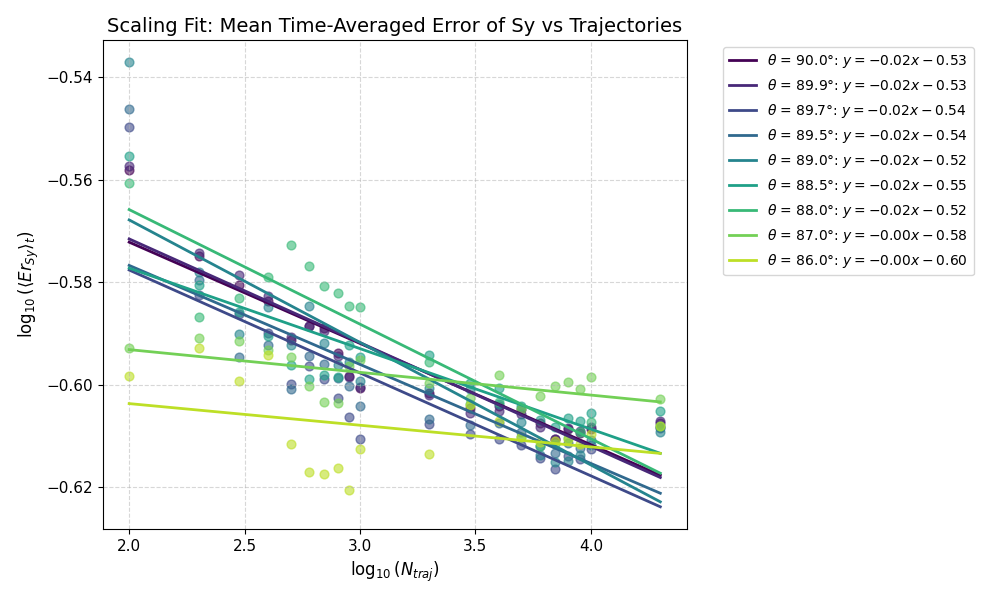

In [13]:
# ====================================================================
# ANGLE-BY-ANGLE FIT & PLOT: MEAN ERROR OF Sy vs N_TRAJ
# ====================================================================

plt.figure(figsize=(10, 6))

print("--- Angle-by-Angle Fit Results: Mean Error of Sy ---")

# Create a color map to easily distinguish different angles in the plot
colors = plt.cm.viridis(np.linspace(0, 0.9, len(cfg['thetas_deg'])))

for idx, theta in enumerate(cfg['thetas_deg']):
    # Extract the error values for this angle
    mean_err_sy_dict = mean_err_sy_results[theta]
    
    # Filter valid points (must be strictly positive for log10)
    valid_N = []
    valid_err = []
    for N in N_traj_list:
        err_val = mean_err_sy_dict[N]
        if err_val > 0:
            valid_N.append(N)
            valid_err.append(err_val)
            
    # Convert lists to arrays for math operations
    x_data = np.array(valid_N)
    y_data = np.array(valid_err)
    
    # Take logarithms for the log-log fit
    log_x = np.log10(x_data)
    log_y = np.log10(y_data)
    
    # Perform linear regression: log(Error) = slope * log(N) + intercept
    slope, intercept, r_value, p_value, std_err = linregress(log_x, log_y)
    print(f"Angle {theta:^4}° -> Slope: {slope:+.4f} | Intercept: {intercept:+.4f} | R^2: {r_value**2:.4f}")
    
    color = colors[idx]
    
    # Plot the original scatter points in log-log space
    plt.scatter(log_x, log_y, color=color, alpha=0.6, marker='o', s=40)
    
    # Generate the theoretical fit line points
    x_fit = np.linspace(min(log_x), max(log_x), 100)
    y_fit = slope * x_fit + intercept
    
    # Plot the fit line and include the equation in the legend
    plt.plot(x_fit, y_fit, color=color, linewidth=2, 
             label=f'$\\theta$ = {theta}°: $y = {slope:.2f}x {intercept:+.2f}$')

# Formatting the plot
plt.xlabel(r"$\log_{10}(N_{traj})$", fontsize=12)
plt.ylabel(r"$\log_{10}(\langle Er_{Sy} \rangle_t)$", fontsize=12)
plt.title("Scaling Fit: Mean Time-Averaged Error of Sy vs Trajectories", fontsize=14)

# Place the legend outside the plot area
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# ---------------------
# FIGURE SAVING FOR Sy
# ---------------------

# Dynamically set the output directory using the base path
Output_dir = os.path.join(base_output_dir, "Sy")

# Check if the directory exists, otherwise create it
if not os.path.exists(Output_dir):
    os.makedirs(Output_dir)
    print(f"Created directory: {Output_dir}")

# Save the figure 
save_fig(plt.gcf(), "Fit_Error_Sy")

# Display the plot
plt.show()